In [56]:
import pandas as pd

observations = pd.read_csv("observations.csv")

print(observations.head(5))

species = pd.read_csv("species_info.csv")

print(species.head(5))

print("Number of species")
print(len(species))

print("Number of observations")
print(len(observations))

print("Number of missings conservation")
print(species['conservation_status'].isna().sum())
print("Length", f"{len(species)}")

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic 

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

print(observations.describe(include="all"))
print(observations.columns)

print(species.describe())



         scientific_name                            park_name  observations
count              23296                                23296  23296.000000
unique              5541                                    4           NaN
top     Myotis lucifugus  Great Smoky Mountains National Park           NaN
freq                  12                                 5824           NaN
mean                 NaN                                  NaN    142.287904
std                  NaN                                  NaN     69.890532
min                  NaN                                  NaN      9.000000
25%                  NaN                                  NaN     86.000000
50%                  NaN                                  NaN    124.000000
75%                  NaN                                  NaN    195.000000
max                  NaN                                  NaN    321.000000
Index(['scientific_name', 'park_name', 'observations'], dtype='object')
              ca

conservation_status
Species of Concern    161
Endangered             16
Threatened             10
In Recovery             4
Name: count, dtype: int64
category
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: count, dtype: int64


<Axes: xlabel='category'>

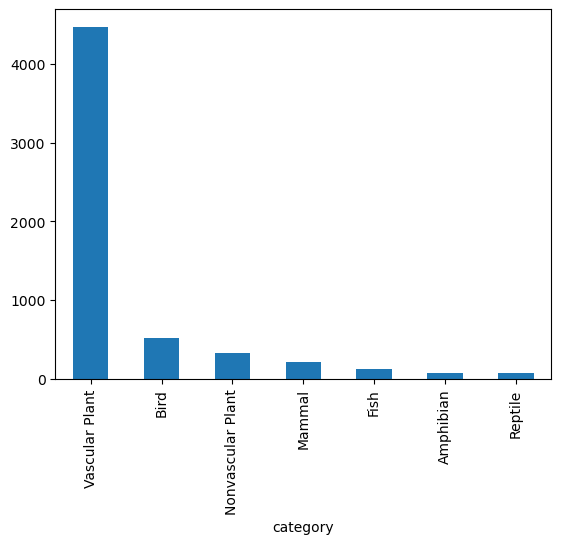

In [58]:
print(species['conservation_status'].value_counts())
print(species['category'].value_counts())

print(species[species.conservation_status == "Endangered"].groupby("category"))
species['category'].value_counts().plot(kind='bar')

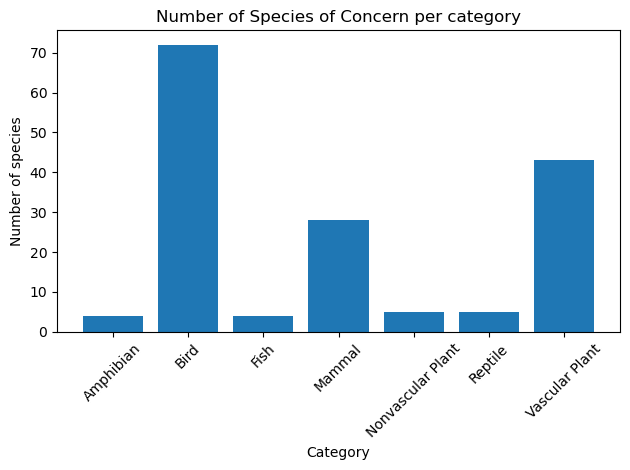

In [59]:

counts = species[species.conservation_status == "Species of Concern"].groupby('category').count()

plt.bar(counts.index, counts['scientific_name'])
plt.title("Number of Species of Concern per category")
plt.xlabel("Category")
plt.ylabel("Number of species")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<BarContainer object of 4 artists>

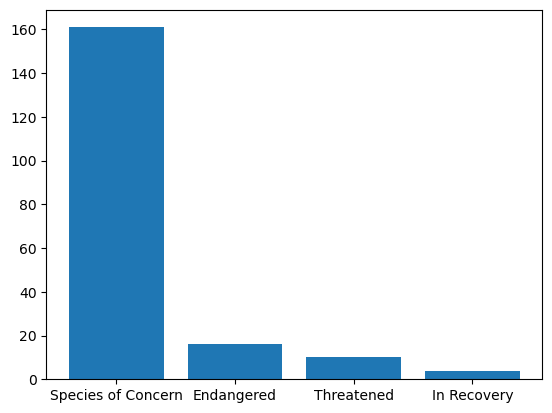

In [63]:
counts = species['conservation_status'].value_counts()

plt.bar(counts.index, counts.values)

category             Amphibian  Bird  Fish  Mammal  Nonvascular Plant  \
conservation_status                                                     
Endangered                   1     4     3       7                  0   
In Recovery                  0     3     0       1                  0   
Species of Concern           4    72     4      28                  5   
Threatened                   2     0     4       2                  0   

category             Reptile  Vascular Plant  
conservation_status                           
Endangered                 0               1  
In Recovery                0               0  
Species of Concern         5              43  
Threatened                 0               2  


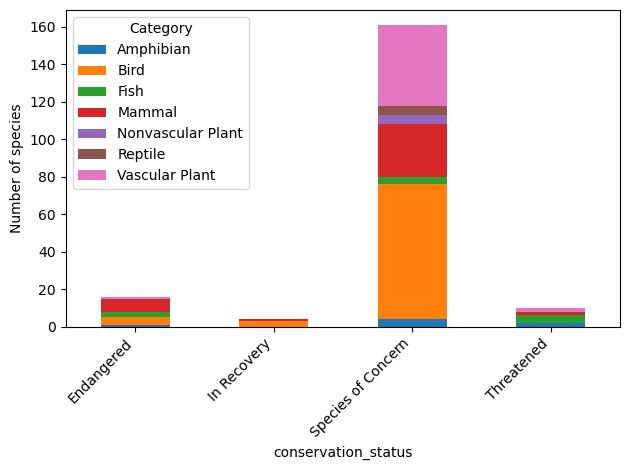

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a pivot table: status as rows, category as columns, counts as values
table = pd.crosstab(species['conservation_status'], species['category'])

print(table)

table.plot(kind='bar', stacked=True)
plt.ylabel('Number of species')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.tight_layout()
plt.show()